In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [19]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_granularity(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for)
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append(str(granularity[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(xlabel = 'iterazioni per job',ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.63, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nmatrix size: {n_size}\nsleep every column 1ms\nruns: {len(data_for)}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [20]:
def plot_speedup_granularity(data_list,title,gran,n_threads): #primo data in data_list è for normale e poi si compara con quello
    fig, ax = plt.subplots(figsize=[16, 8])

    data_mean = [np.mean(datum) for datum in data_list]
    speedup = np.zeros(len(gran))


    for i in range(len(gran)):
        speedup[i] = data_mean[0]/data_mean[i+1]
        

    #print(data_list)
    #print(data_mean)
    gran = gran[::-1]
    speedup = speedup[::-1]
    ax.plot(gran,speedup,'o--')

    y = lambda x: np.minimum(n_size/x,n_threads)
    ax.plot(gran,y(np.array(gran)), 'o--')

    ax.legend(['speedup','maximum'])
    ax.set_title(title, loc= 'left')
    ax.set_xticks(gran)
    ax.set_xticklabels(gran, rotation = 45)


    ax.set(xlabel = 'graularity'+str(gran),ylabel = 'speedup')
    plt.figtext(0.7, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nmatrix size: {n_size}\nsleep every column 1ms", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [4]:
!rm *.txt

rm: cannot remove '*.txt': No such file or directory


In [25]:
#a mano settali uguali a come runnato in cluster 
#set parameter
n_runs = 50
n_size = 160 #costo singola iterazione
n_threads = 16
size_queue = 64
granularity = [160,80,20,10,5,1]

In [ ]:
#run manualmente for seq,   nruns sizematrix
!./for_sleep.sh 50 10000

In [ ]:
#run granularity for (per ogni n un run di .sh) runs sizematrix thread queuesize granularity
!./parallel_for_sleep.sh 50 100 6 64 4

In [26]:
# run test granularity
dati_for = []
dati_for = np.genfromtxt("test_for_matrix_sleep.txt",delimiter=',',dtype=int)[:-1]
dati_parallel_for_sure_gran = []
for i,nb in enumerate(granularity):
    dati_parallel_for_sure_gran.append(np.genfromtxt("test_parallel_for_matrix_sleep_gr"+str(nb)+".txt",delimiter=',',dtype=int)[:-1])

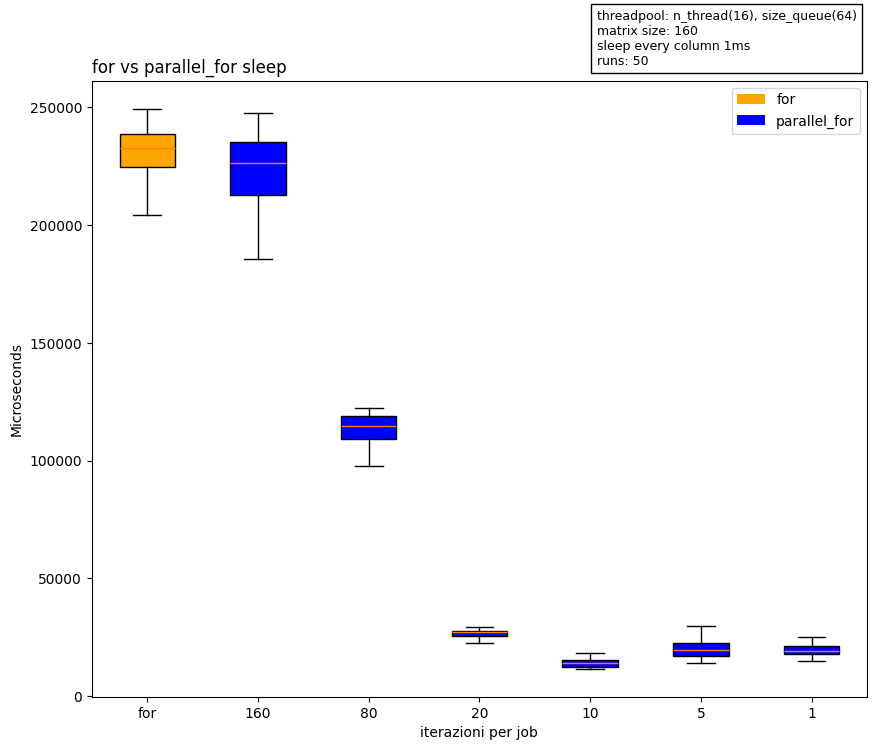

In [27]:
plot_granularity(dati_for, dati_parallel_for_sure_gran,"for vs parallel_for sleep")

su 50 iniziali tenuti 48 per for sequential
su 50 iniziali tenuti 50 per granularity 160
su 50 iniziali tenuti 47 per granularity 80
su 50 iniziali tenuti 50 per granularity 20
su 50 iniziali tenuti 49 per granularity 10
su 50 iniziali tenuti 49 per granularity 5
su 50 iniziali tenuti 46 per granularity 1


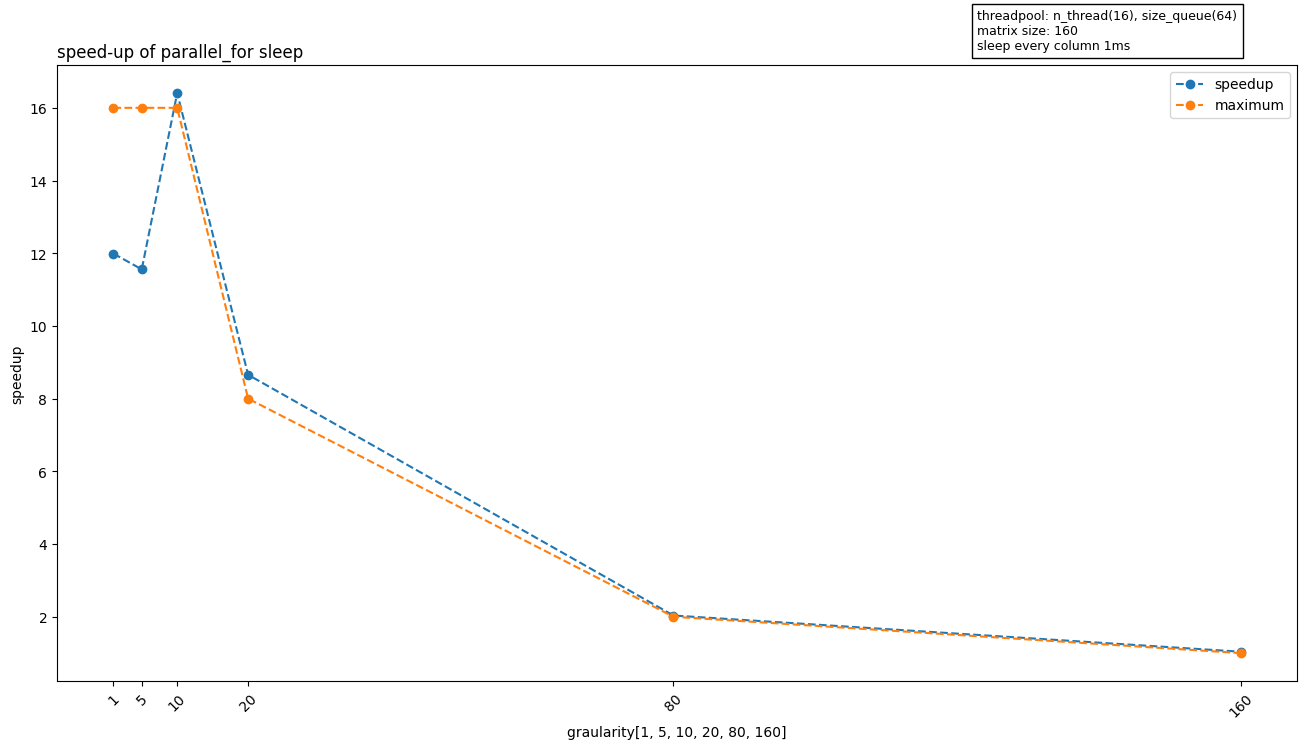

In [28]:
data_list = []
data_list.append(dati_for)
# Calcolo Q1, Q3 e IQR
Q1 = np.percentile(data_list[0], 25)
Q3 = np.percentile(data_list[0], 75)
IQR = Q3 - Q1

# Limiti per gli outlier
limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR
#print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
# Filtro
data_list[0] = data_list[0][(data_list[0] >= limite_inferiore) & (data_list[0] <= limite_superiore)]
print(f"su {len(dati_for)} iniziali tenuti {len(data_list[0])} per for sequential")
for i in range(len(granularity)):
    data_list.append(dati_parallel_for_sure_gran[i])
    # Calcolo Q1, Q3 e IQR
    Q1 = np.percentile(data_list[i+1], 25)
    Q3 = np.percentile(data_list[i+1], 75)
    IQR = Q3 - Q1

    # Limiti per gli outlier
    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR
   # print(Q1,Q3,IQR,limite_inferiore,limite_superiore)
    # Filtro
    data_list[i+1] = data_list[i+1][(data_list[i+1] >= limite_inferiore) & (data_list[i+1] <= limite_superiore)]
    print(f"su {len(dati_parallel_for_sure_gran[0])} iniziali tenuti {len(data_list[i+1])} per granularity {granularity[i]}")
plot_speedup_granularity(data_list,"speed-up of parallel_for sleep",granularity,n_threads)